In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

plays = pd.read_csv('fbs_fbs_wildcats.csv')

C:\Users\bchm5\AppData\Local\Temp\ipykernel_30500\2348594209.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('fbs_fbs_wildcats.csv')


In [6]:
# set all plays
plays.loc[:, 'first_down_gained_numeric'] = \
    plays['first_down_gained'].fillna(0)

offensive_plays = ['designed run', 'dropback']  # adjust to match your actual values

plays = plays[plays['play_type'].isin(offensive_plays)]

teams = plays.groupby(['season', 'offense']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    avg_yards=('gain_loss', 'median')
).reset_index().sort_values(['season', 'first_down_rate'], ascending=[True, False])

# set wildcats
wildcats = plays[plays['wildcat_play'] == 1]
non_wildcat = plays[plays['wildcat_play'] == 0]

wildcat_teams = wildcats.groupby(['season', 'offense']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    avg_yards=('gain_loss', 'median')
).reset_index().sort_values(['season', 'first_down_rate'], ascending=[True, False])
wildcat_teams.sort_values('plays', ascending=False)

,season,offense,plays,first_down_rate,avg_yards
97,2025,UTUN,45,0.422222,4.0
39,2025,LATC,43,0.255814,3.0
52,2025,MSUN,37,0.567568,2.0
61,2025,NVLV,27,0.444444,6.0
27,2025,ILNO,26,0.692308,2.0
...,...,...,...,...,...
56,2025,NCST,1,0.000000,0.0
70,2025,OHUN,1,0.000000,3.0
57,2025,NCUN,1,0.000000,-2.0
83,2025,TNVA,1,0.000000,-2.0


In [3]:
def assign_distance(d):
    if d < 4: return 'Short (< 4 yds)'
    elif d <= 8: return 'Medium (4-8 yds)'
    else: return 'Long (9+ yds)'

down_order = {1: 'Down 1', 2: 'Down 2', 3: 'Down 3', 4: 'Down 4'}

wildcats = plays[plays['wildcat_play'] == 1].copy()
wildcats['down_label'] = wildcats['down'].map(down_order)

wildcats['distance_bucket'] = wildcats['distance'].apply(assign_distance)

wildcat_distances = wildcats[wildcats['wildcat_position'].isin(['HB', 'WR', 'TE'])].groupby(['down_label', 'distance_bucket', 'play_type', 'wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean')
).reset_index()

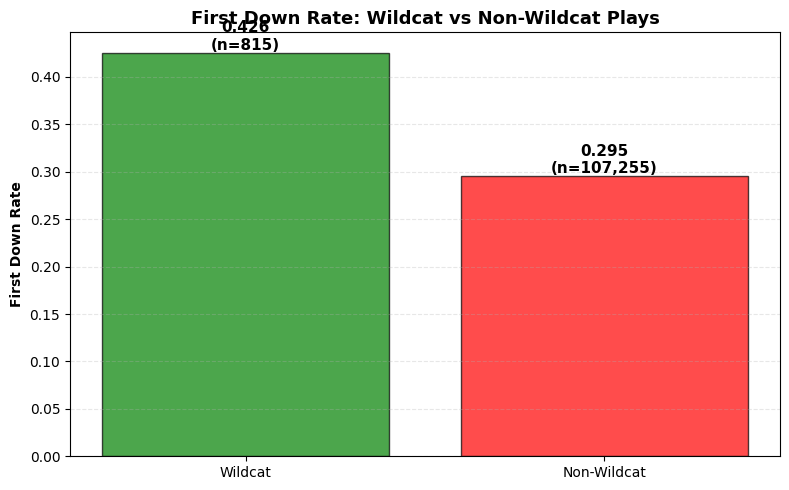

In [3]:
wildcat = plays[plays['wildcat_play'] == 1]
non_wildcat = plays[plays['wildcat_play'] == 0]

comparison = pd.DataFrame({
    'group': ['Wildcat', 'Non-Wildcat'],
    'first_down_rate': [
        wildcat['first_down_gained_numeric'].mean(),
        non_wildcat['first_down_gained_numeric'].mean()
    ],
    'plays': [len(wildcat), len(non_wildcat)]
})

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['green' if r > comparison['first_down_rate'].mean() else 'red' for r in comparison['first_down_rate']]
bars = ax.bar(comparison['group'], comparison['first_down_rate'], color=colors, alpha=0.7, edgecolor='black')

for bar, (_, row) in zip(bars, comparison.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{row['first_down_rate']:.3f}\n(n={row['plays']:,})",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('First Down Rate', fontweight='bold')
ax.set_title('First Down Rate: Wildcat vs Non-Wildcat Plays', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

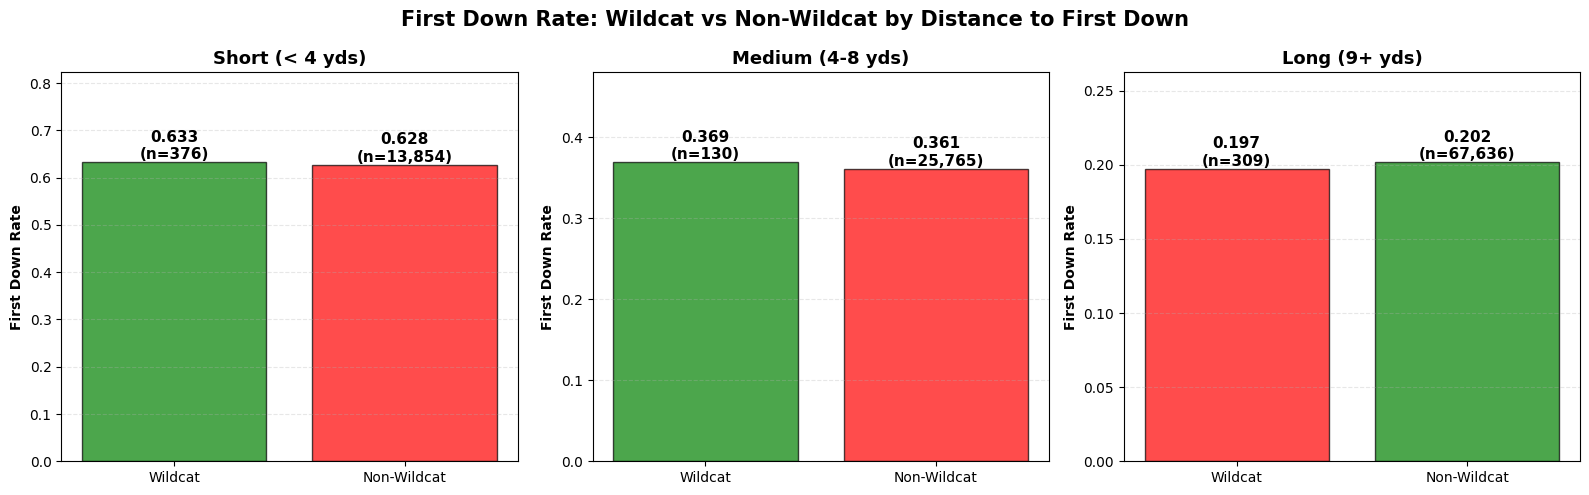

In [7]:
distance_buckets = ['Short (< 4 yds)', 'Medium (4-8 yds)', 'Long (9+ yds)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, bucket in enumerate(distance_buckets):
    wildcat_bucket = plays.copy()
    wildcat_bucket['distance_bucket'] = wildcat_bucket['distance'].apply(assign_distance)
    
    wildcat_dist = wildcat_bucket[(wildcat_bucket['wildcat_play'] == 1) & (wildcat_bucket['distance_bucket'] == bucket)]
    non_wildcat_dist = wildcat_bucket[(wildcat_bucket['wildcat_play'] == 0) & (wildcat_bucket['distance_bucket'] == bucket)]

    comparison = pd.DataFrame({
        'group': ['Wildcat', 'Non-Wildcat'],
        'first_down_rate': [
            wildcat_dist['first_down_gained_numeric'].mean(),
            non_wildcat_dist['first_down_gained_numeric'].mean()
        ],
        'plays': [len(wildcat_dist), len(non_wildcat_dist)]
    })

    ax = axes[i]
    colors = ['green' if r > comparison['first_down_rate'].mean() else 'red' for r in comparison['first_down_rate']]
    bars = ax.bar(comparison['group'], comparison['first_down_rate'], color=colors, alpha=0.7, edgecolor='black')

    for bar, (_, row) in zip(bars, comparison.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{row['first_down_rate']:.3f}\n(n={row['plays']:,})",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_title(f'{bucket}', fontweight='bold', fontsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(comparison['first_down_rate']) * 1.3)

plt.suptitle('First Down Rate: Wildcat vs Non-Wildcat by Distance to First Down',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

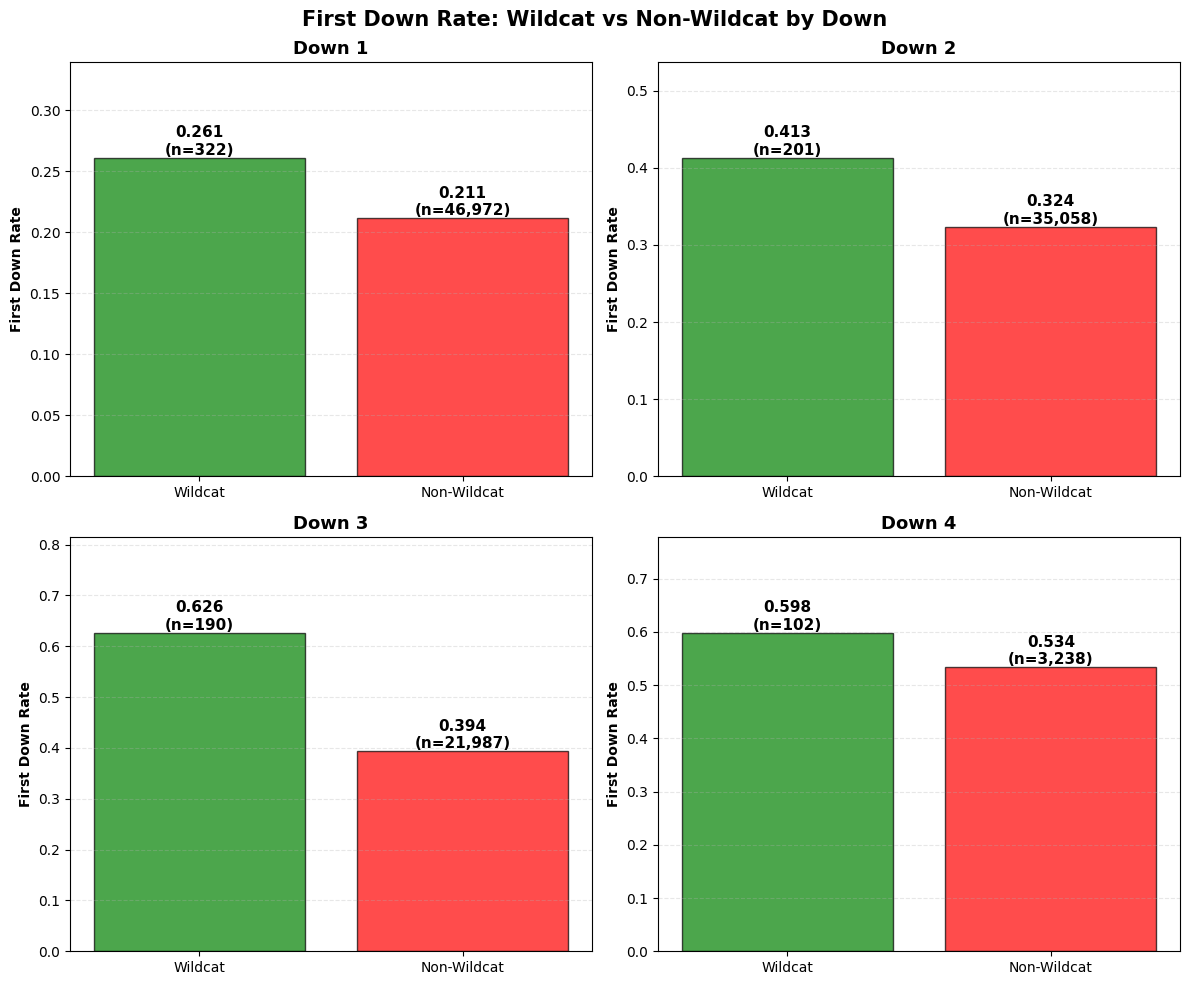

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, down in enumerate([1, 2, 3, 4]):
    wildcat_down = plays[(plays['wildcat_play'] == 1) & (plays['down'] == down)]
    non_wildcat_down = plays[(plays['wildcat_play'] == 0) & (plays['down'] == down)]

    comparison = pd.DataFrame({
        'group': ['Wildcat', 'Non-Wildcat'],
        'first_down_rate': [
            wildcat_down['first_down_gained_numeric'].mean(),
            non_wildcat_down['first_down_gained_numeric'].mean()
        ],
        'plays': [len(wildcat_down), len(non_wildcat_down)]
    })

    ax = axes[i]
    colors = ['green' if r > comparison['first_down_rate'].mean() else 'red' for r in comparison['first_down_rate']]
    bars = ax.bar(comparison['group'], comparison['first_down_rate'], color=colors, alpha=0.7, edgecolor='black')

    for bar, (_, row) in zip(bars, comparison.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{row['first_down_rate']:.3f}\n(n={row['plays']:,})",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_title(f'Down {down}', fontweight='bold', fontsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(comparison['first_down_rate']) * 1.3)

plt.suptitle('First Down Rate: Wildcat vs Non-Wildcat by Down', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

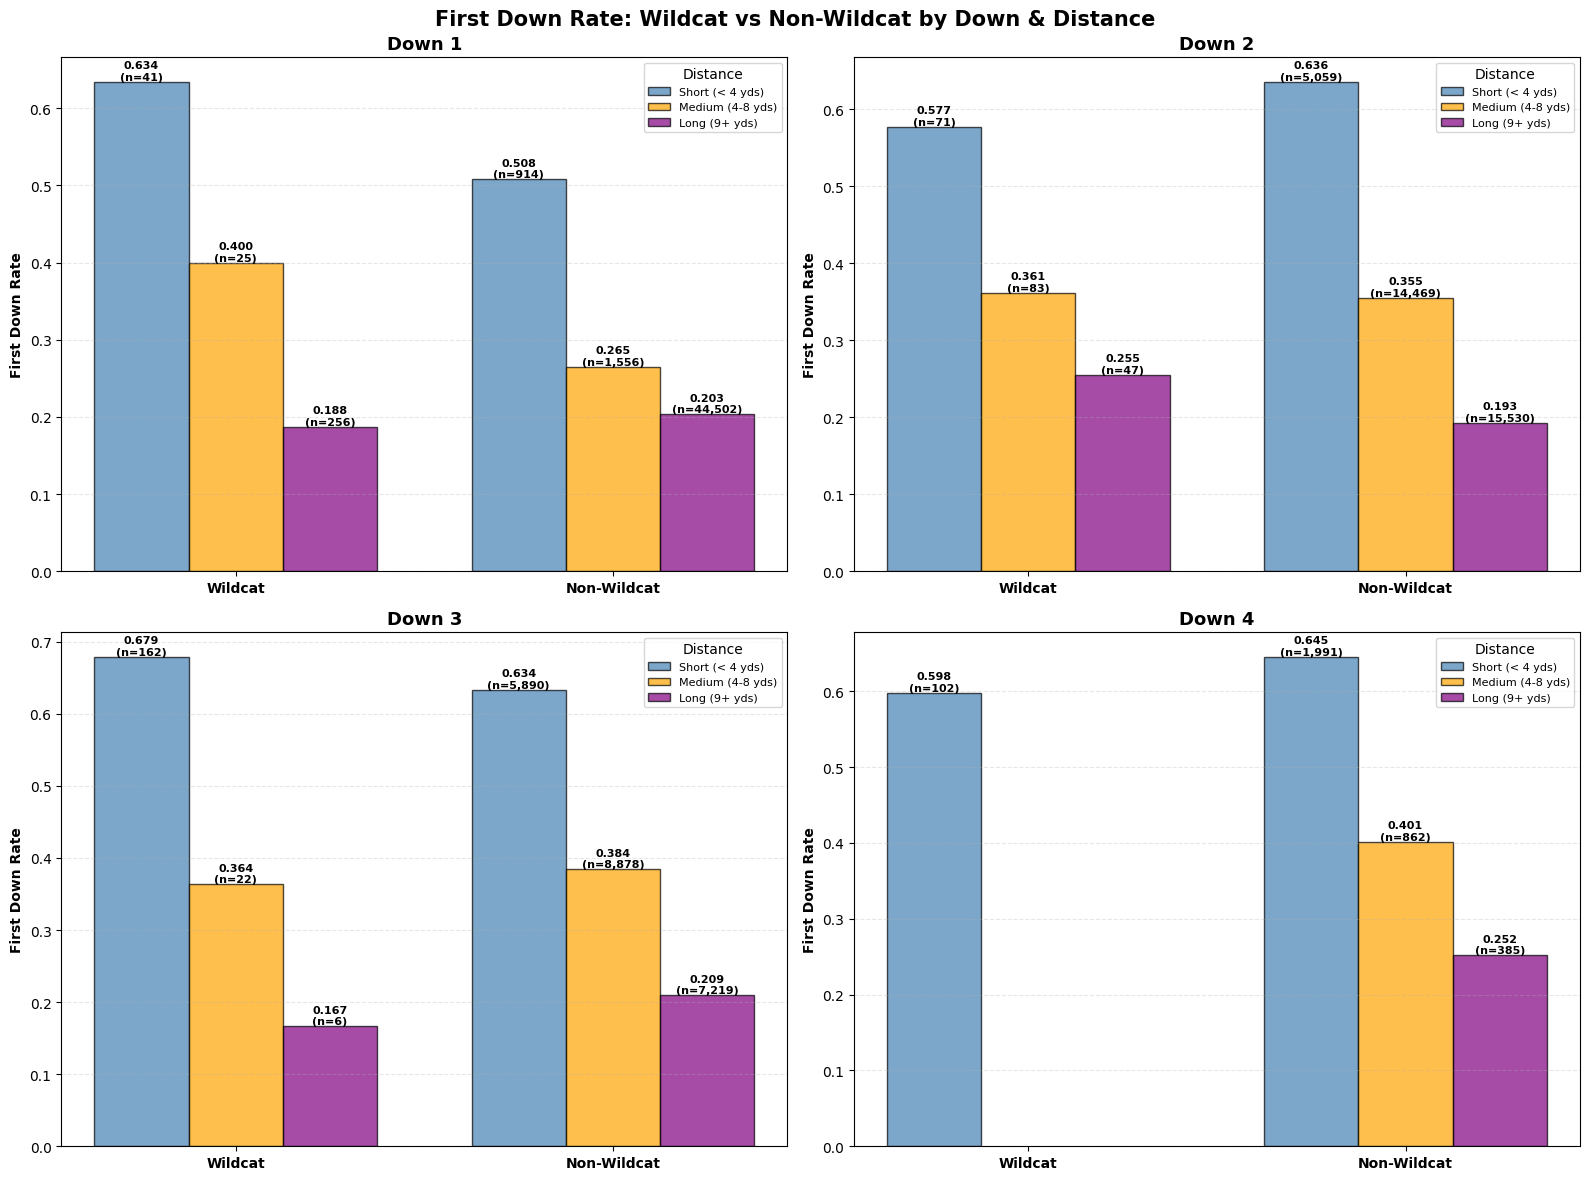

In [10]:
distance_buckets = ['Short (< 4 yds)', 'Medium (4-8 yds)', 'Long (9+ yds)']
distance_colors = {'Short (< 4 yds)': 'steelblue', 'Medium (4-8 yds)': 'orange', 'Long (9+ yds)': 'purple'}
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, down in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    
    for j, bucket in enumerate(distance_buckets):
        wildcat_down = plays_with_distance[
            (plays_with_distance['wildcat_play'] == 1) & 
            (plays_with_distance['down'] == down) & 
            (plays_with_distance['distance_bucket'] == bucket)
        ]
        non_wildcat_down = plays_with_distance[
            (plays_with_distance['wildcat_play'] == 0) & 
            (plays_with_distance['down'] == down) & 
            (plays_with_distance['distance_bucket'] == bucket)
        ]

        fd_wildcat = wildcat_down['first_down_gained_numeric'].mean()
        fd_non_wildcat = non_wildcat_down['first_down_gained_numeric'].mean()
        
        x = np.array([0, 1])
        offset = (j - 1) * width
        color = distance_colors[bucket]

        bars = ax.bar(x + offset, [fd_wildcat, fd_non_wildcat], width,
                      label=bucket, color=color, alpha=0.7, edgecolor='black')

        for bar, (fd, n) in zip(bars, [(fd_wildcat, len(wildcat_down)), (fd_non_wildcat, len(non_wildcat_down))]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{fd:.3f}\n(n={n:,})",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Wildcat', 'Non-Wildcat'], fontweight='bold')
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_title(f'Down {down}', fontweight='bold', fontsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, title='Distance')

plt.suptitle('First Down Rate: Wildcat vs Non-Wildcat by Down & Distance',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

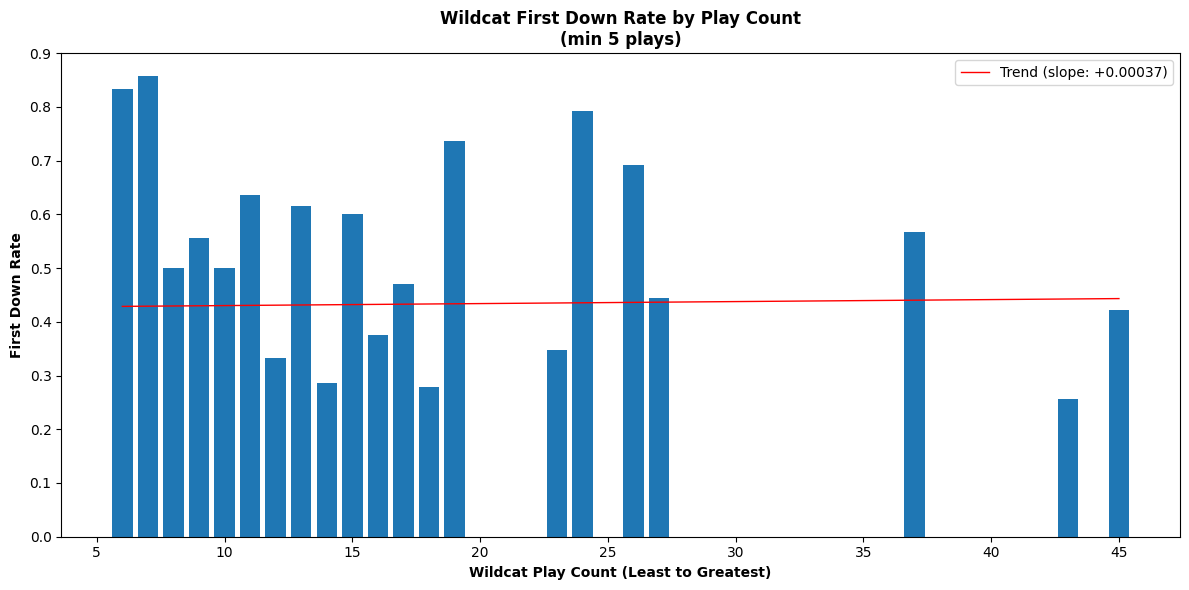

In [5]:
# Filter and sort
filtered = (
    wildcat_teams[wildcat_teams['plays'] > 5]
    .sort_values(by='plays', ascending=True)
)

x = filtered['plays']
y = filtered['first_down_rate']

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x, y)

# ----- Regression Line -----
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
slope = z[0]

# Smooth line across range
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p(x_line), linewidth=1, color='red',
         label=f'Trend (slope: {slope:+.5f})')

plt.xlabel('Wildcat Play Count (Least to Greatest)', fontweight='bold')
plt.ylabel('First Down Rate', fontweight='bold')
plt.title('Wildcat First Down Rate by Play Count\n(min 5 plays)',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

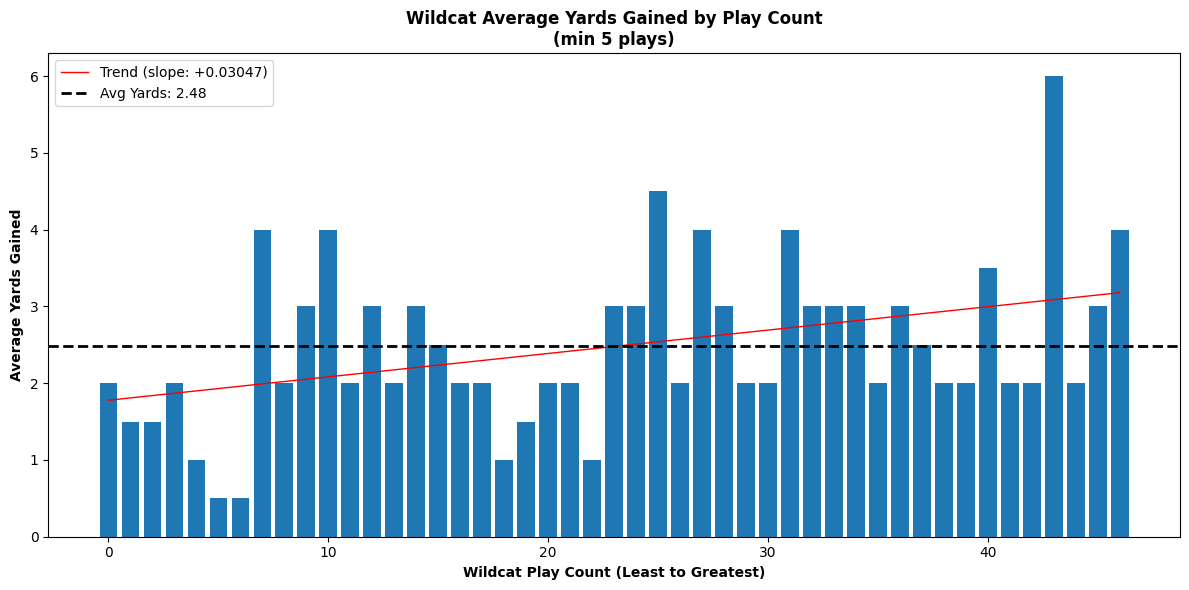

In [11]:
x = np.arange(len(filtered))
y = filtered['avg_yards'].values

avg_yards = y.mean()


plt.figure(figsize=(12, 6))

plt.bar(x, y)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
slope = z[0]

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p(x_line), linewidth=1, color='red',
         label=f'Trend (slope: {slope:+.5f})')

plt.axhline(avg_yards, color='black', linestyle='--', linewidth=2,
            label=f'Avg Yards: {avg_yards:.2f}')

plt.xlabel('Wildcat Play Count (Least to Greatest)', fontweight='bold')
plt.ylabel('Average Yards Gained', fontweight='bold')
plt.title('Wildcat Average Yards Gained by Play Count\n(min 5 plays)',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

0.7659574468085106
0.875


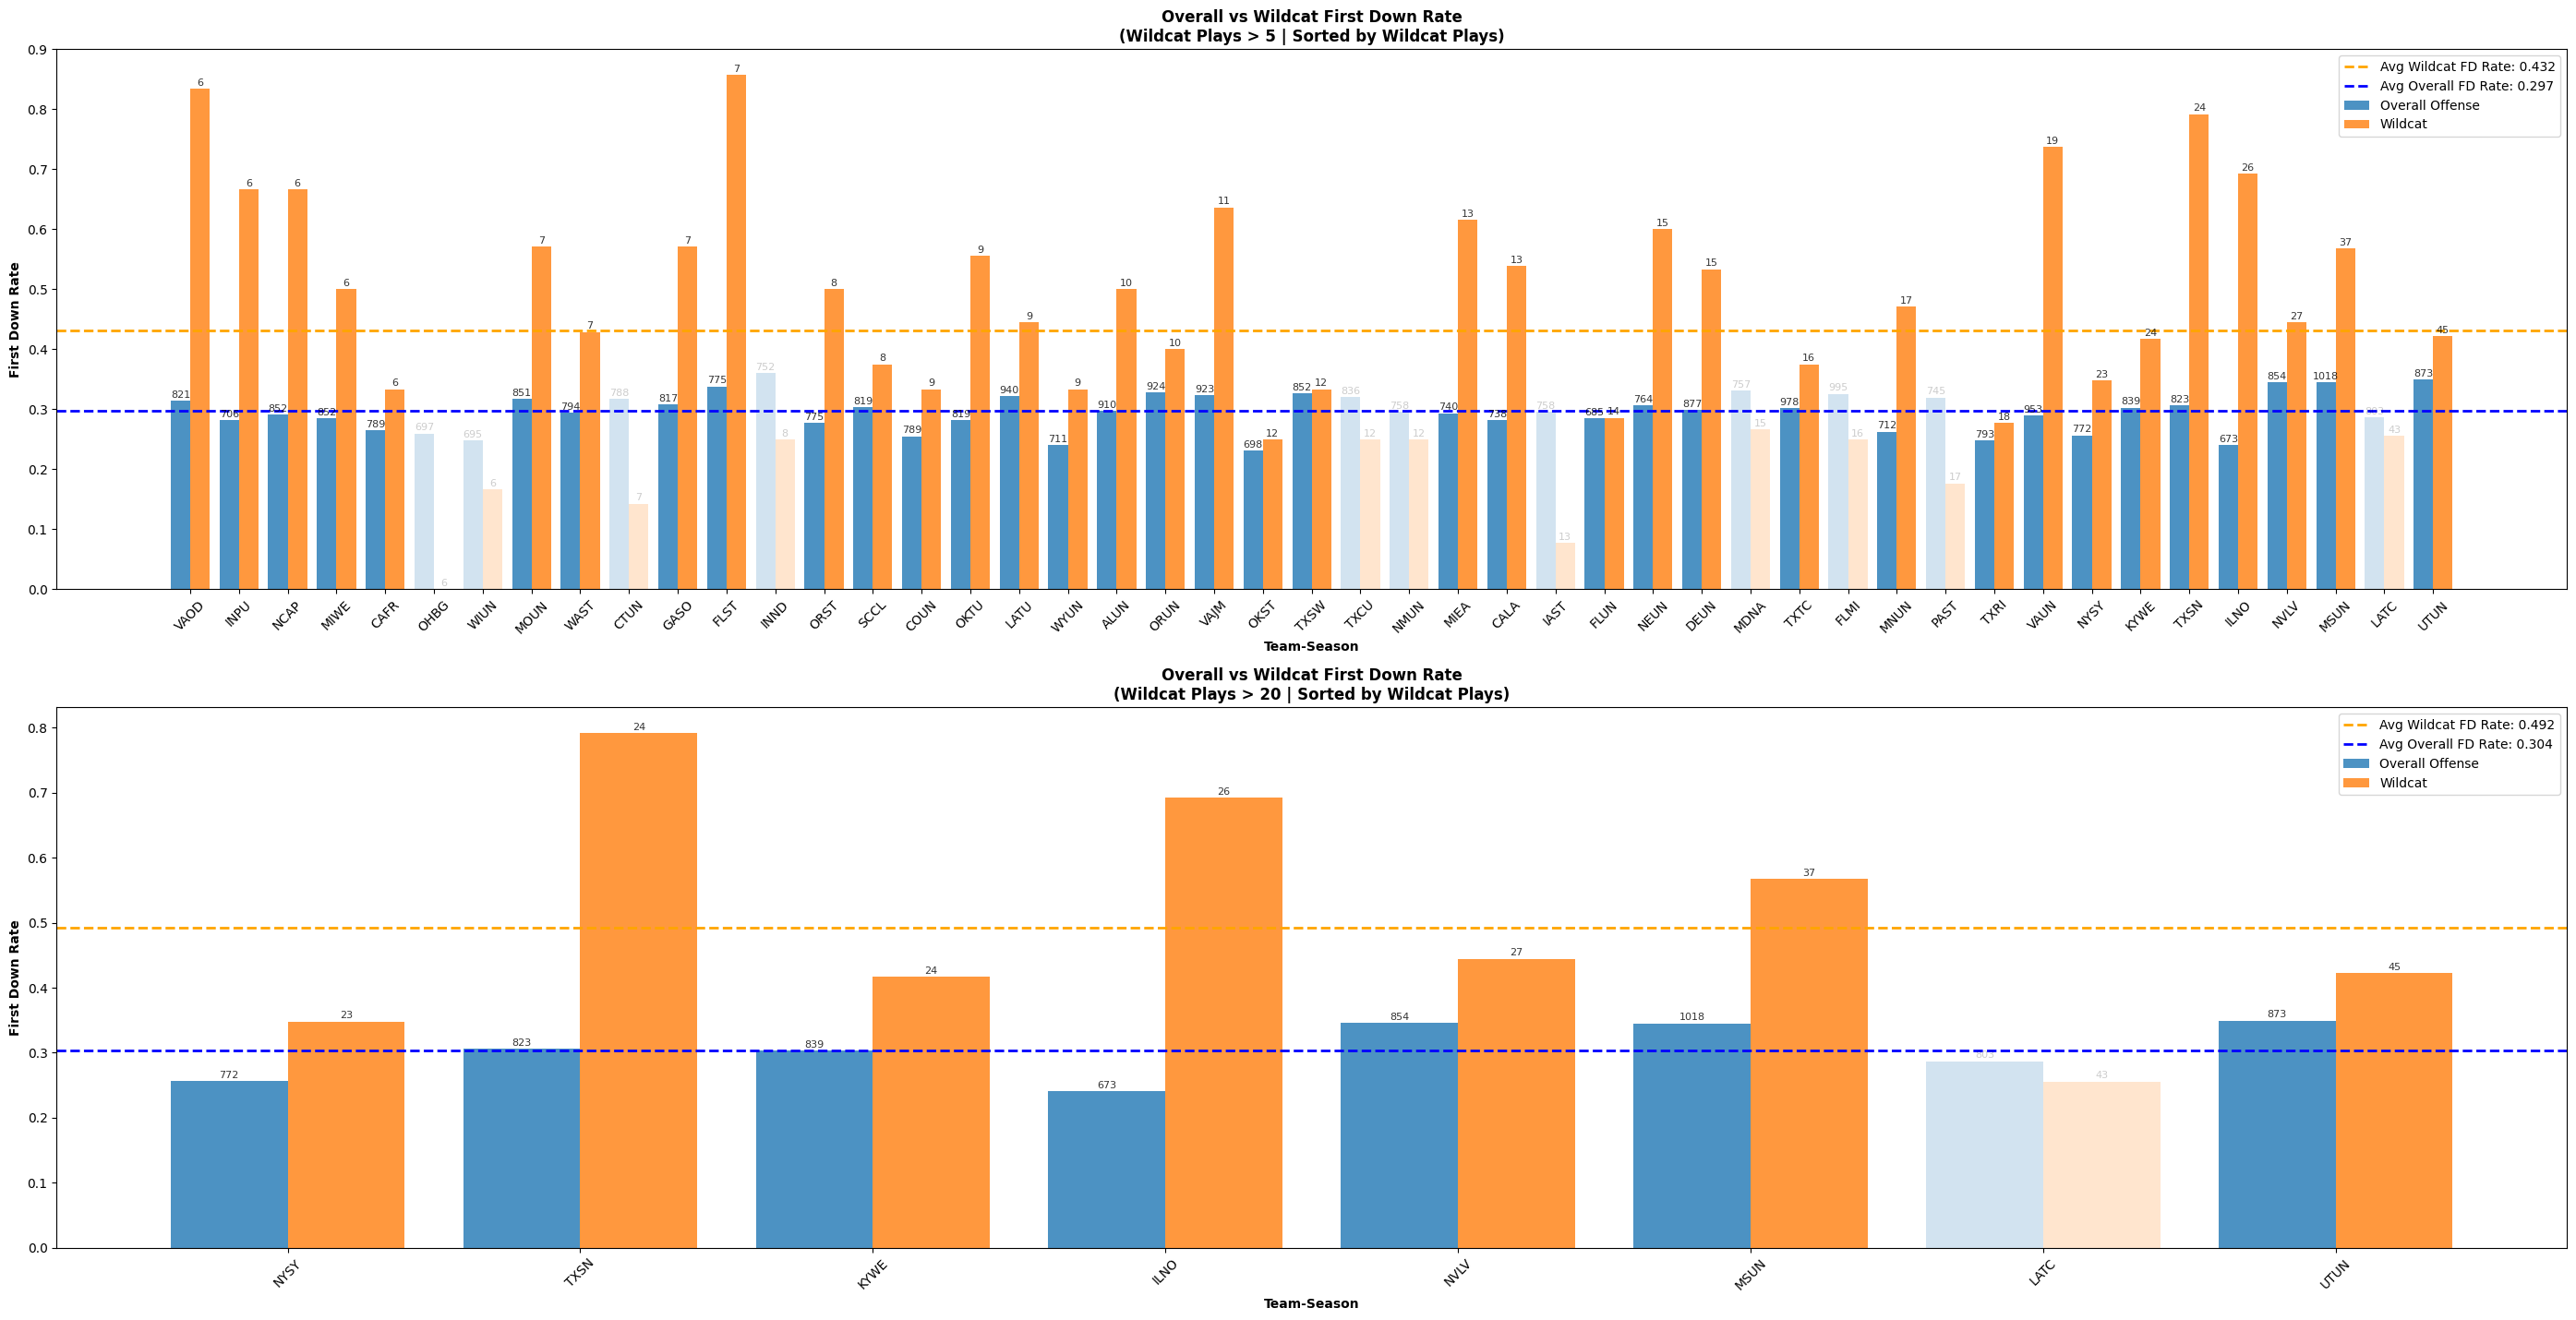

In [7]:
merged = pd.merge(
    wildcat_teams,
    teams,
    on=['season', 'offense'],
    suffixes=('_wildcat', '_overall')
)

small_merged = merged[
    (merged['plays_wildcat'] > 5) &
    (merged['plays_overall'] > 500)
].sort_values(by='plays_wildcat', ascending=True)

big_merged = merged[
    (merged['plays_wildcat'] > 20) &
    (merged['plays_overall'] > 500)
].sort_values(by='plays_wildcat', ascending=True)

data_list = [small_merged, big_merged]
titles = ['Wildcat Plays > 5', 'Wildcat Plays > 20']

width = 0.4

sort_options = ['plays_wildcat', 'plays_overall', 'first_down_rate_wildcat', 'first_down_rate_overall']
sort_labels  = ['Wildcat Plays', 'Overall Plays', 'Wildcat FD Rate', 'Overall FD Rate']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 16))
plt.subplots_adjust(bottom=0.25)

def draw_ax(ax, data, sort_col, title_suffix, filter_label):
    ax.clear()

    plot_data = data.sort_values(by=sort_col, ascending=True)
    xi = np.arange(len(plot_data))

    alphas = [
        0.8 if o < w else 0.2
        for o, w in zip(
            plot_data['first_down_rate_overall'],
            plot_data['first_down_rate_wildcat']
        )
    ]

    bars1 = ax.bar(xi - width/2, plot_data['first_down_rate_overall'], width, label='Overall Offense')
    for bar, alpha in zip(bars1, alphas):
        bar.set_alpha(alpha)

    total_count = 0
    wildcat_better_count = 0

    bars2 = ax.bar(xi + width/2, plot_data['first_down_rate_wildcat'], width, label='Wildcat')
    for bar, alpha in zip(bars2, alphas):
        total_count += 1
        if alpha == 0.8:
            wildcat_better_count += 1
        bar.set_alpha(alpha)

    better_rate = wildcat_better_count/total_count
    print(better_rate)

    for i in range(len(plot_data)):
        alpha_text = alphas[i]
        ax.text(xi[i] - width/2, plot_data['first_down_rate_overall'].iloc[i] + 0.005,
                f"{plot_data['plays_overall'].iloc[i]}", ha='center', fontsize=8,
                color=(0, 0, 0, alpha_text))
        ax.text(xi[i] + width/2, plot_data['first_down_rate_wildcat'].iloc[i] + 0.005,
                f"{plot_data['plays_wildcat'].iloc[i]}", ha='center', fontsize=8,
                color=(0, 0, 0, alpha_text))

    avg_wildcat = plot_data['first_down_rate_wildcat'].mean()
    avg_overall = plot_data['first_down_rate_overall'].mean()

    ax.axhline(avg_wildcat, color='orange', linestyle='--', linewidth=2,
            label=f'Avg Wildcat FD Rate: {avg_wildcat:.3f}')
    ax.axhline(avg_overall, color='blue', linestyle='--', linewidth=2,
            label=f'Avg Overall FD Rate: {avg_overall:.3f}')


    ax.set_xlabel('Team-Season', fontweight='bold')
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_title(f'Overall vs Wildcat First Down Rate\n({filter_label} | Sorted by {title_suffix})', fontweight='bold')
    ax.set_xticks(xi)
    ax.set_xticklabels(plot_data['offense'], rotation=45)
    ax.legend()

idx = {'ax1': 0, 'ax2': 0}

draw_ax(ax1, small_merged, sort_options[idx['ax1']], sort_labels[idx['ax1']], titles[0])

draw_ax(ax2, big_merged,   sort_options[idx['ax2']], sort_labels[idx['ax2']], titles[1])

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

Wildcat better rate: 0.043
Wildcat better rate: 0.125


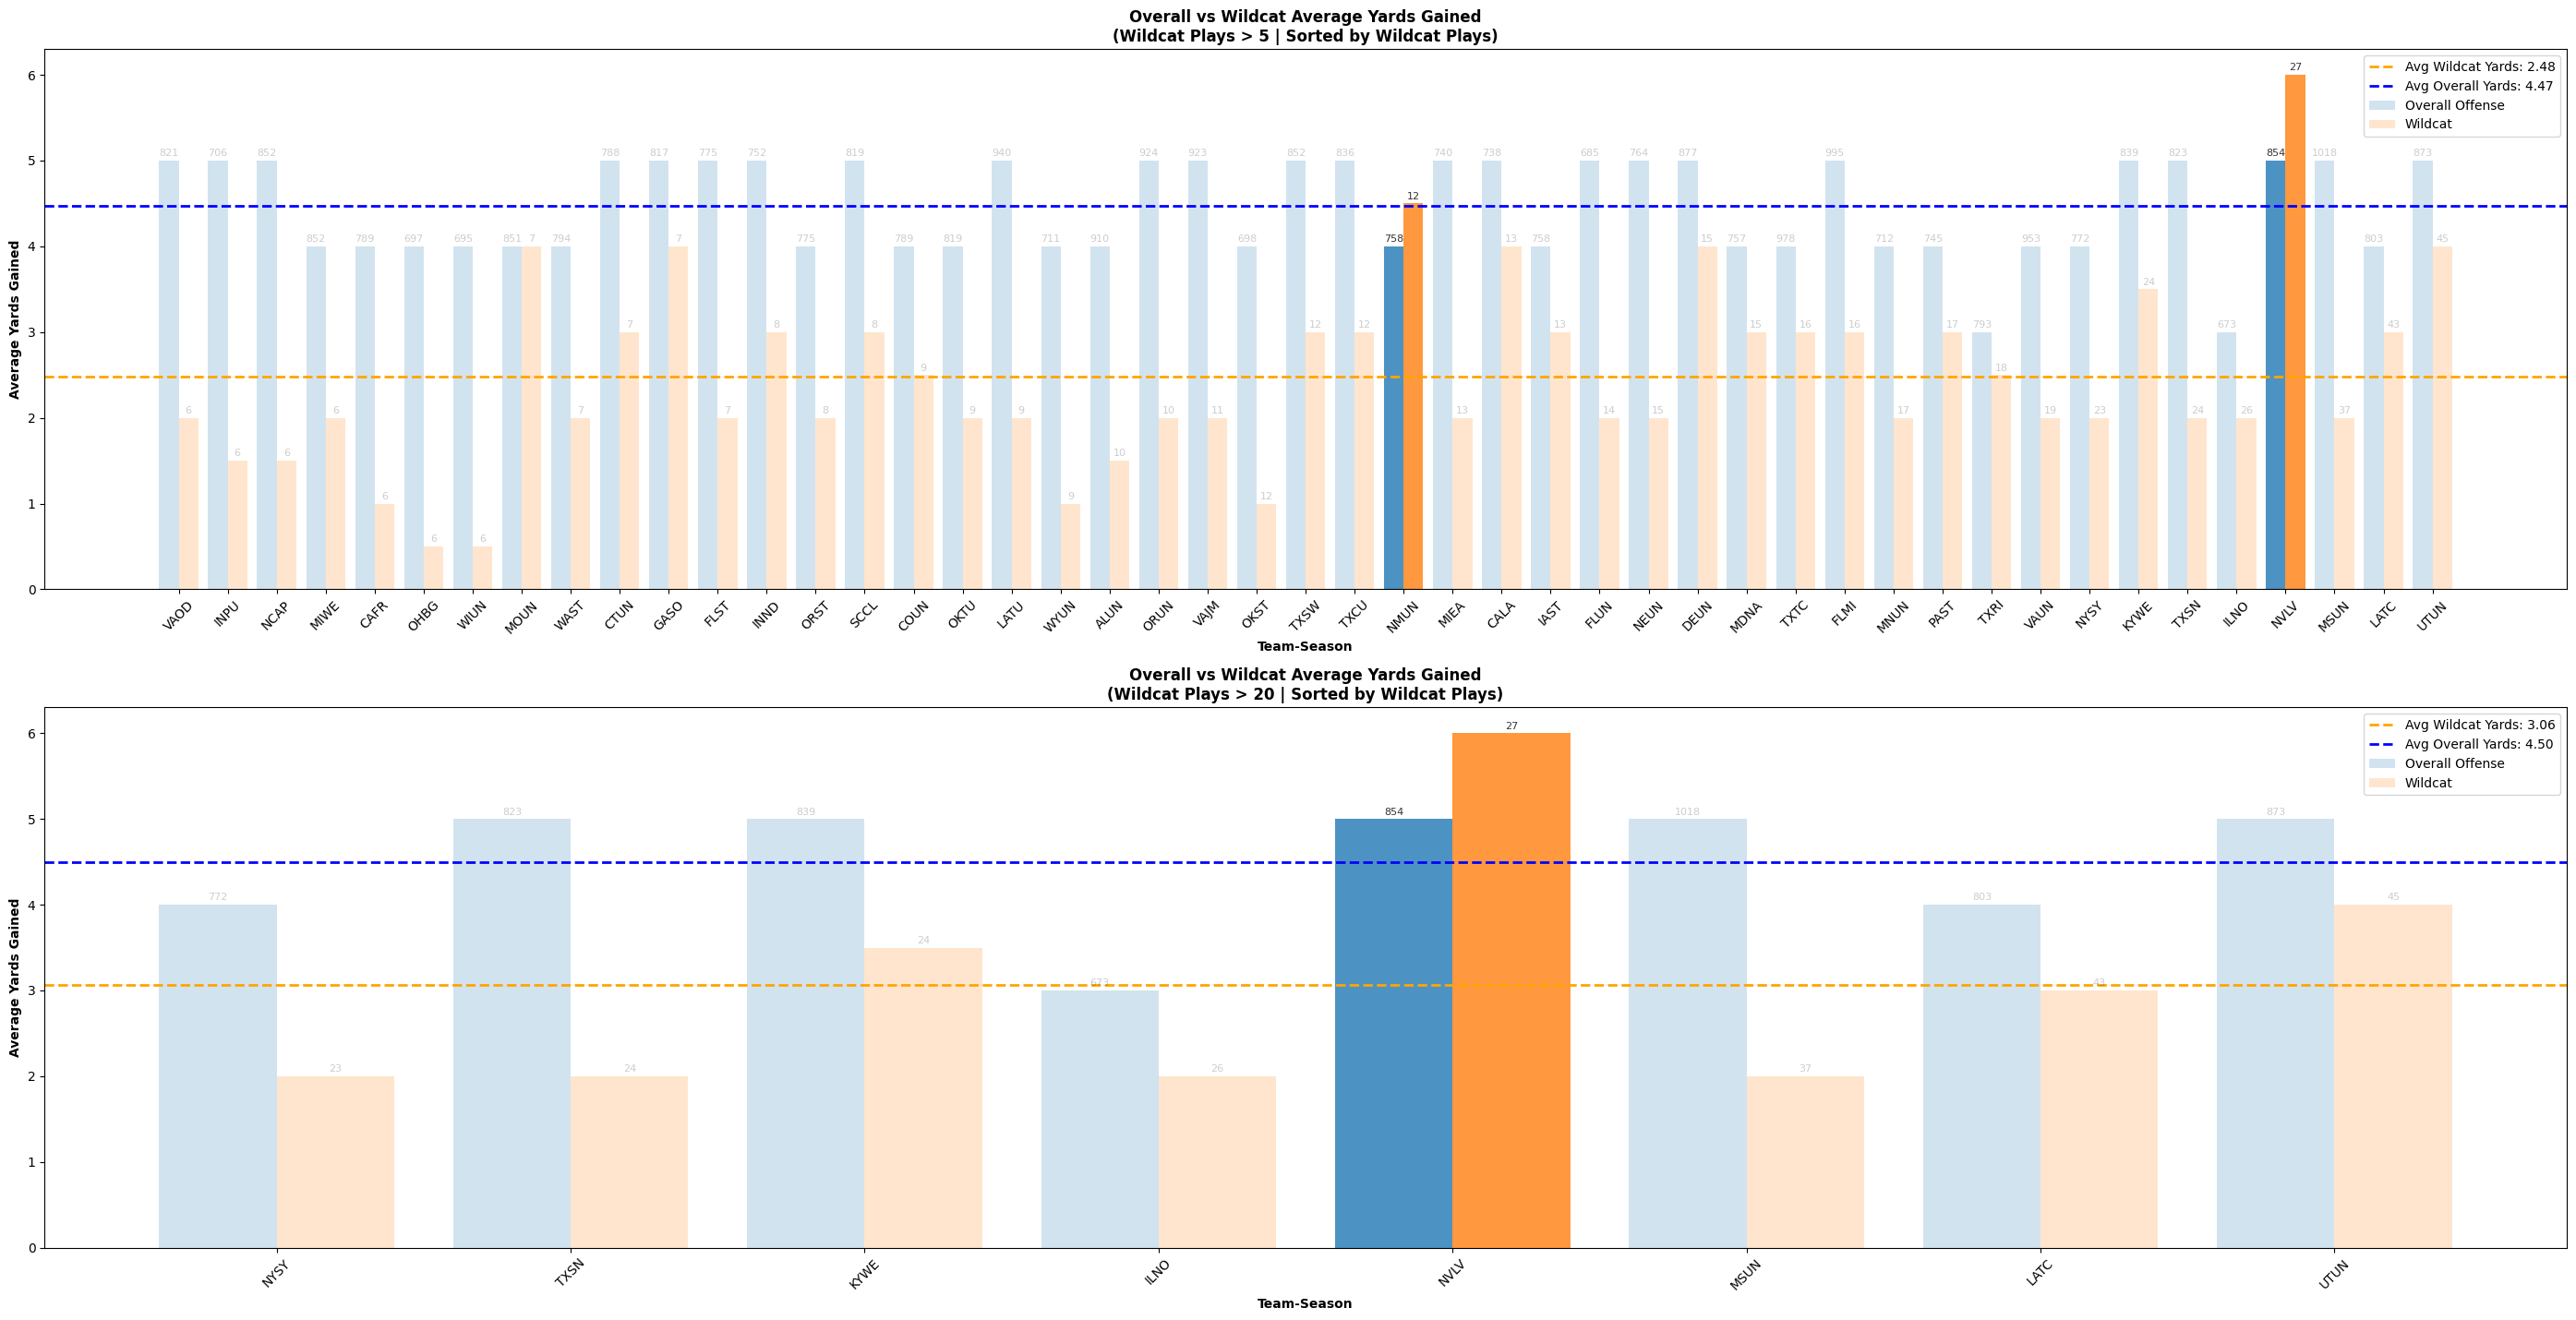

In [8]:
merged = pd.merge(
    wildcat_teams,
    teams,
    on=['season', 'offense'],
    suffixes=('_wildcat', '_overall')
)

small_merged = merged[
    (merged['plays_wildcat'] > 5) &
    (merged['plays_overall'] > 500)
].sort_values(by='plays_wildcat', ascending=True)

big_merged = merged[
    (merged['plays_wildcat'] > 20) &
    (merged['plays_overall'] > 500)
].sort_values(by='plays_wildcat', ascending=True)

titles = ['Wildcat Plays > 5', 'Wildcat Plays > 20']
width = 0.4

sort_options = ['plays_wildcat', 'plays_overall', 'avg_yards_wildcat', 'avg_yards_overall']
sort_labels  = ['Wildcat Plays', 'Overall Plays', 'Wildcat Avg Yards', 'Overall Avg Yards']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 16))
plt.subplots_adjust(bottom=0.25)

def draw_ax_yards(ax, data, sort_col, title_suffix, filter_label):
    ax.clear()

    plot_data = data.sort_values(by=sort_col, ascending=True)
    xi = np.arange(len(plot_data))

    alphas = [
        0.8 if o < w else 0.2
        for o, w in zip(
            plot_data['avg_yards_overall'],
            plot_data['avg_yards_wildcat']
        )
    ]

    bars1 = ax.bar(xi - width/2, plot_data['avg_yards_overall'], width, label='Overall Offense')
    for bar, alpha in zip(bars1, alphas):
        bar.set_alpha(alpha)

    total_count = 0
    wildcat_better_count = 0

    bars2 = ax.bar(xi + width/2, plot_data['avg_yards_wildcat'], width, label='Wildcat')
    for bar, alpha in zip(bars2, alphas):
        total_count += 1
        if alpha == 0.8:
            wildcat_better_count += 1
        bar.set_alpha(alpha)

    better_rate = wildcat_better_count / total_count
    print(f"Wildcat better rate: {better_rate:.3f}")

    for i in range(len(plot_data)):
        alpha_text = alphas[i]
        ax.text(xi[i] - width/2, plot_data['avg_yards_overall'].iloc[i] + 0.05,
                f"{plot_data['plays_overall'].iloc[i]}", ha='center', fontsize=8,
                color=(0, 0, 0, alpha_text))
        ax.text(xi[i] + width/2, plot_data['avg_yards_wildcat'].iloc[i] + 0.05,
                f"{plot_data['plays_wildcat'].iloc[i]}", ha='center', fontsize=8,
                color=(0, 0, 0, alpha_text))

    avg_wildcat = plot_data['avg_yards_wildcat'].mean()
    avg_overall = plot_data['avg_yards_overall'].mean()

    ax.axhline(avg_wildcat, color='orange', linestyle='--', linewidth=2,
               label=f'Avg Wildcat Yards: {avg_wildcat:.2f}')
    ax.axhline(avg_overall, color='blue', linestyle='--', linewidth=2,
               label=f'Avg Overall Yards: {avg_overall:.2f}')

    ax.set_xlabel('Team-Season', fontweight='bold')
    ax.set_ylabel('Average Yards Gained', fontweight='bold')
    ax.set_title(f'Overall vs Wildcat Average Yards Gained\n({filter_label} | Sorted by {title_suffix})', fontweight='bold')
    ax.set_xticks(xi)
    ax.set_xticklabels(plot_data['offense'], rotation=45)
    ax.legend()

idx = {'ax1': 0, 'ax2': 0}

draw_ax_yards(ax1, small_merged, sort_options[idx['ax1']], sort_labels[idx['ax1']], titles[0])
draw_ax_yards(ax2, big_merged,   sort_options[idx['ax2']], sort_labels[idx['ax2']], titles[1])

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [9]:
print(plays[plays['no_play'] == 0]['gain_loss'].describe())
print(plays[plays['no_play'] == 1]['gain_loss'].describe())
    

count    88897.000000
mean         6.847756
std          9.927344
min        -40.000000
25%          2.000000
50%          4.000000
75%          9.000000
max         98.000000
Name: gain_loss, dtype: float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: gain_loss, dtype: float64


In [ ]:
# for col in wildcats.select_dtypes(include='number').columns:
#     if abs(wildcats['first_down_gained_numeric'].corr(wildcats[col])) > 0.078:
#         print(col, "   ", round(wildcats['first_down_gained_numeric'].corr(wildcats[col]), 4))

In [18]:
offensive_plays = ['designed run', 'dropback']  # adjust to match your actual values

plays.loc[:, 'first_down_gained_numeric'] = \
    plays['first_down_gained'].fillna(0)

plays = plays[plays['play_type'].isin(offensive_plays)]

goalline = plays[(plays['down'] == 1) & (plays['distance'] < 4) & (plays['play_type'] == 'designed run')]
goalline_wildcat = goalline[(goalline['wildcat_play'] == 1) & plays['wildcat_position'].isin(['HB', 'WR', 'TE'])]
goalline_normal = goalline[goalline['wildcat_play'] == 0]

print(f"Goalline Overall:  {goalline['first_down_gained_numeric'].mean():.3f} (n={len(goalline):,})")
print(f"Goalline Wildcat:  {goalline_wildcat['first_down_gained_numeric'].mean():.3f} (n={len(goalline_wildcat):,})")
print(f"Goalline Normal:   {goalline_normal['first_down_gained_numeric'].mean():.3f} (n={len(goalline_normal):,})")

print(goalline_wildcat.groupby('wildcat_position').agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean')
).reset_index().sort_values('first_down_rate', ascending=False))


Goalline Overall:  0.512 (n=849)
Goalline Wildcat:  0.649 (n=37)
Goalline Normal:   0.507 (n=809)
  wildcat_position  plays  first_down_rate
0               HB     30         0.766667
2               WR      3         0.333333
1               TE      4         0.000000


C:\Users\bchm5\AppData\Local\Temp\ipykernel_30500\1039948077.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  goalline_wildcat = goalline[(goalline['wildcat_play'] == 1) & plays['wildcat_position'].isin(['HB', 'WR', 'TE'])]


| Feature | Correlation |
|---|---|
| **Positive** | |
| down | 0.3211 |
| box_players_on_los_count | 0.2036 |
| yards_after_contact | 0.1893 |
| box_players_count | 0.1703 |
| pass_depth | 0.1623 |
| yards_after_catch | 0.1533 |
| num_pass_blockers | 0.1482 |
| missed_tackle | 0.1281 |
| trick_play | 0.1003 |
| def_penalty | 0.0853 |
| drive_play | 0.0782 |
| **Negative** | |
| distance | -0.3751 |
| drive_end_field_position | -0.2372 |
| safety_count | -0.1561 |
| bunched_count | -0.1127 |
| unbalanced | -0.1013 |
| pressure | -0.0949 |
| option | -0.0942 |
